# Per-plant F1 vs feature mean — paper revision

Replaces the older `3_general_plot.ipynb` scatter (which used the deprecated
`TROPOMI_US/data/Run_20250623_203825` path).

Key changes:
1. **Full-CSV `dropna()` first**, matching `train_mlp.py` and
   `7_analyze_model_performance_by_plant.py`. Reason: per-plant F1 in
   `per_plant_performance_metrics.csv` was computed on the dropna'd obs (the
   MLP needs all 25 input features non-NaN to predict). For the scatter to
   represent "F1 vs the plant's typical condition during the obs we
   evaluated", the feature mean must use the SAME obs subset as the F1.
2. No additional plant-level / interference filter — the inner-merge with
   `per_plant_performance_metrics.csv` already restricts to the 171 / ~1065
   non-interfered plants the F1 numbers were computed on.
3. Updated to the **100 m wind** datasets (US `Run_100m_20260414`, Global
   `Run_100m_20260428`), with Global per-scene scalar features merged from
   `Run_3` on `(location, utc_time)` (same recipe as `9_pod_2d_heatmaps.ipynb`).

Output: `pod_f1_vs_features.{pdf,png}` in `results/paper_figures/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from scipy import stats

# Paths
US_OBS_CSV     = Path('/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/'
                       'Run_100m_20260414/'
                       'updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv')
WORLD_LBL_CSV  = Path('/net/fs06/d3/rzhuang/TROPOMI/data/world/'
                       'pipeline_test_labelling_100m/Run_100m_20260428/'
                       'valid_tropomi_emissions_with_qa.csv')
WORLD_FEAT_CSV = Path('/net/fs06/d3/rzhuang/TROPOMI/data/world/Run_3/'
                       'updated_tropomi_emissions_full_variables_with_fuel.csv')

US_PERF_CSV    = Path('/net/fs06/d3/rzhuang/TROPOMI_US/results/'
                       'per_plant_performance_metrics.csv')
WORLD_PERF_CSV = Path('/net/fs06/d3/rzhuang/TROPOMI_world/results/'
                       'per_plant_performance_metrics.csv')

OUT_DIR = Path('/net/fs06/d3/rzhuang/TROPOMI/results/paper_figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Style
nimbus = next((p for p in fm.findSystemFonts()
               if 'nimbusroman' in p.lower() and 'bold' not in p.lower()
               and 'italic' not in p.lower()), None)
if nimbus:
    fm.fontManager.addfont(nimbus)
plt.rcdefaults()
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'Nimbus Roman' if nimbus else 'serif',
    'font.size': 11, 'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
})

COLORS = {'US': '#FF6B6B', 'Global': '#4ECDC4'}

# Features to scatter against F1
FEATURES_LABELS = [
    ('emission',     'NO$_x$ Emission'),
    ('surface_albedo_nitrogendioxide_window', r'Surface Albedo (NO$_2$ Window)'),
    ('sensor_zenith_angle', 'Sensor Zenith Angle (°)'),
    ('wind_speed',   'Wind Speed (m/s)'),
]

def resolve(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f'None of {candidates} in df')

In [2]:
# ── US: load + full dropna() FIRST, then per-plant means ─────────────
# (matches train_mlp.py / 7_analyze_model_performance_by_plant.py: F1 was
#  computed on dropna'd obs, so feature means use the same subset.)
print('Loading US obs ...')
df_us = pd.read_csv(US_OBS_CSV, low_memory=False)
print(f'  raw rows: {len(df_us):,} | plants: {df_us["location"].nunique()}')
df_us = df_us.dropna()
print(f'  after dropna(): {len(df_us):,} | plants: {df_us["location"].nunique()}')

us_emis_col = resolve(df_us, ['NOx Mass (lbs)', 'hourly_emission_rate', 'annual_nox_emission'])
us_alb_col  = resolve(df_us, ['surface_albedo_nitrogendioxide_window'])
us_szn_col  = resolve(df_us, ['sensor_zenith_angle'])
us_wind_col = resolve(df_us, ['wind_speed', 'wind_speed_10m', '10m_wind_speed'])

# Convert lbs -> kg/h for plot readability if needed
if 'lbs' in us_emis_col.lower():
    df_us['emission_kgh'] = pd.to_numeric(df_us[us_emis_col], errors='coerce') * 0.45359237
    us_emis_col = 'emission_kgh'

us_feature_map = {
    'emission': us_emis_col,
    'surface_albedo_nitrogendioxide_window': us_alb_col,
    'sensor_zenith_angle': us_szn_col,
    'wind_speed': us_wind_col,
}
us_means = (df_us.groupby('location')[list(us_feature_map.values())]
                  .mean().reset_index())
print(f'  per-plant means: {len(us_means)} plants')

Loading US obs ...
  raw rows: 666,222 | plants: 500
  after dropna(): 501,720 | plants: 500
  per-plant means: 500 plants


In [3]:
# ── Global: load 100m label CSV, merge Run_3 features, full dropna() ──
print('Loading Global 100m labels ...')
df_gl_lbl = pd.read_csv(WORLD_LBL_CSV, low_memory=False)
print(f'  100m labels: {len(df_gl_lbl):,} rows | cols: {len(df_gl_lbl.columns)}')

print('Loading Run_3 scalar features ...')
df_gl_feats = pd.read_csv(WORLD_FEAT_CSV, low_memory=False)
print(f'  Run_3 features: {len(df_gl_feats):,} rows | cols: {len(df_gl_feats.columns)}')

# Keep new plume_label + minimal cols on left, bring in Run_3 scalars on right
left_keep = [c for c in ['location', 'utc_time', 'wind_u', 'wind_v', 'plume_label',
                          'country', 'annual_nox_emission']
              if c in df_gl_lbl.columns]
df_gl_lbl_lite = df_gl_lbl[left_keep].copy()
df_gl_feats_lite = df_gl_feats.drop(
    columns=[c for c in df_gl_lbl_lite.columns
             if c in df_gl_feats.columns and c not in ('location', 'utc_time')],
    errors='ignore')
df_gl = df_gl_lbl_lite.merge(df_gl_feats_lite, on=['location', 'utc_time'], how='inner')
print(f'  merged rows: {len(df_gl):,}  ({len(df_gl)/len(df_gl_lbl_lite)*100:.1f}% of new labels)')

df_gl = df_gl.dropna()
print(f'  after dropna(): {len(df_gl):,} | plants: {df_gl["location"].nunique()}')

gl_emis_col = resolve(df_gl, ['annual_nox_emission', 'nox_emis_ty'])
gl_alb_col  = resolve(df_gl, ['surface_albedo_nitrogendioxide_window'])
gl_szn_col  = resolve(df_gl, ['sensor_zenith_angle'])
gl_wind_col = resolve(df_gl, ['wind_speed', 'wind_speed_10m', '10m_wind_speed'])

gl_feature_map = {
    'emission': gl_emis_col,
    'surface_albedo_nitrogendioxide_window': gl_alb_col,
    'sensor_zenith_angle': gl_szn_col,
    'wind_speed': gl_wind_col,
}
gl_means = (df_gl.groupby('location')[list(gl_feature_map.values())]
                  .mean().reset_index())
print(f'  per-plant means: {len(gl_means)} plants')

Loading Global 100m labels ...
  100m labels: 875,686 rows | cols: 14
Loading Run_3 scalar features ...
  Run_3 features: 875,580 rows | cols: 60
  merged rows: 875,580  (100.0% of new labels)
  after dropna(): 875,580 | plants: 6000
  per-plant means: 6000 plants


In [4]:
# ── Merge with per-plant F1 (no further filtering) ───────────────────
us_perf = pd.read_csv(US_PERF_CSV)
gl_perf = pd.read_csv(WORLD_PERF_CSV)
us_id   = 'Facility_ID' if 'Facility_ID' in us_perf.columns else 'location'
gl_id   = 'ID' if 'ID' in gl_perf.columns else 'location'

us_merged = us_perf.merge(us_means, left_on=us_id, right_on='location', how='inner')
gl_merged = gl_perf.merge(gl_means, left_on=gl_id, right_on='location', how='inner')
print(f'US merged plants:     {len(us_merged)}')
print(f'Global merged plants: {len(gl_merged)}')

US merged plants:     171
Global merged plants: 1062


Saved: /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/pod_f1_vs_features.pdf


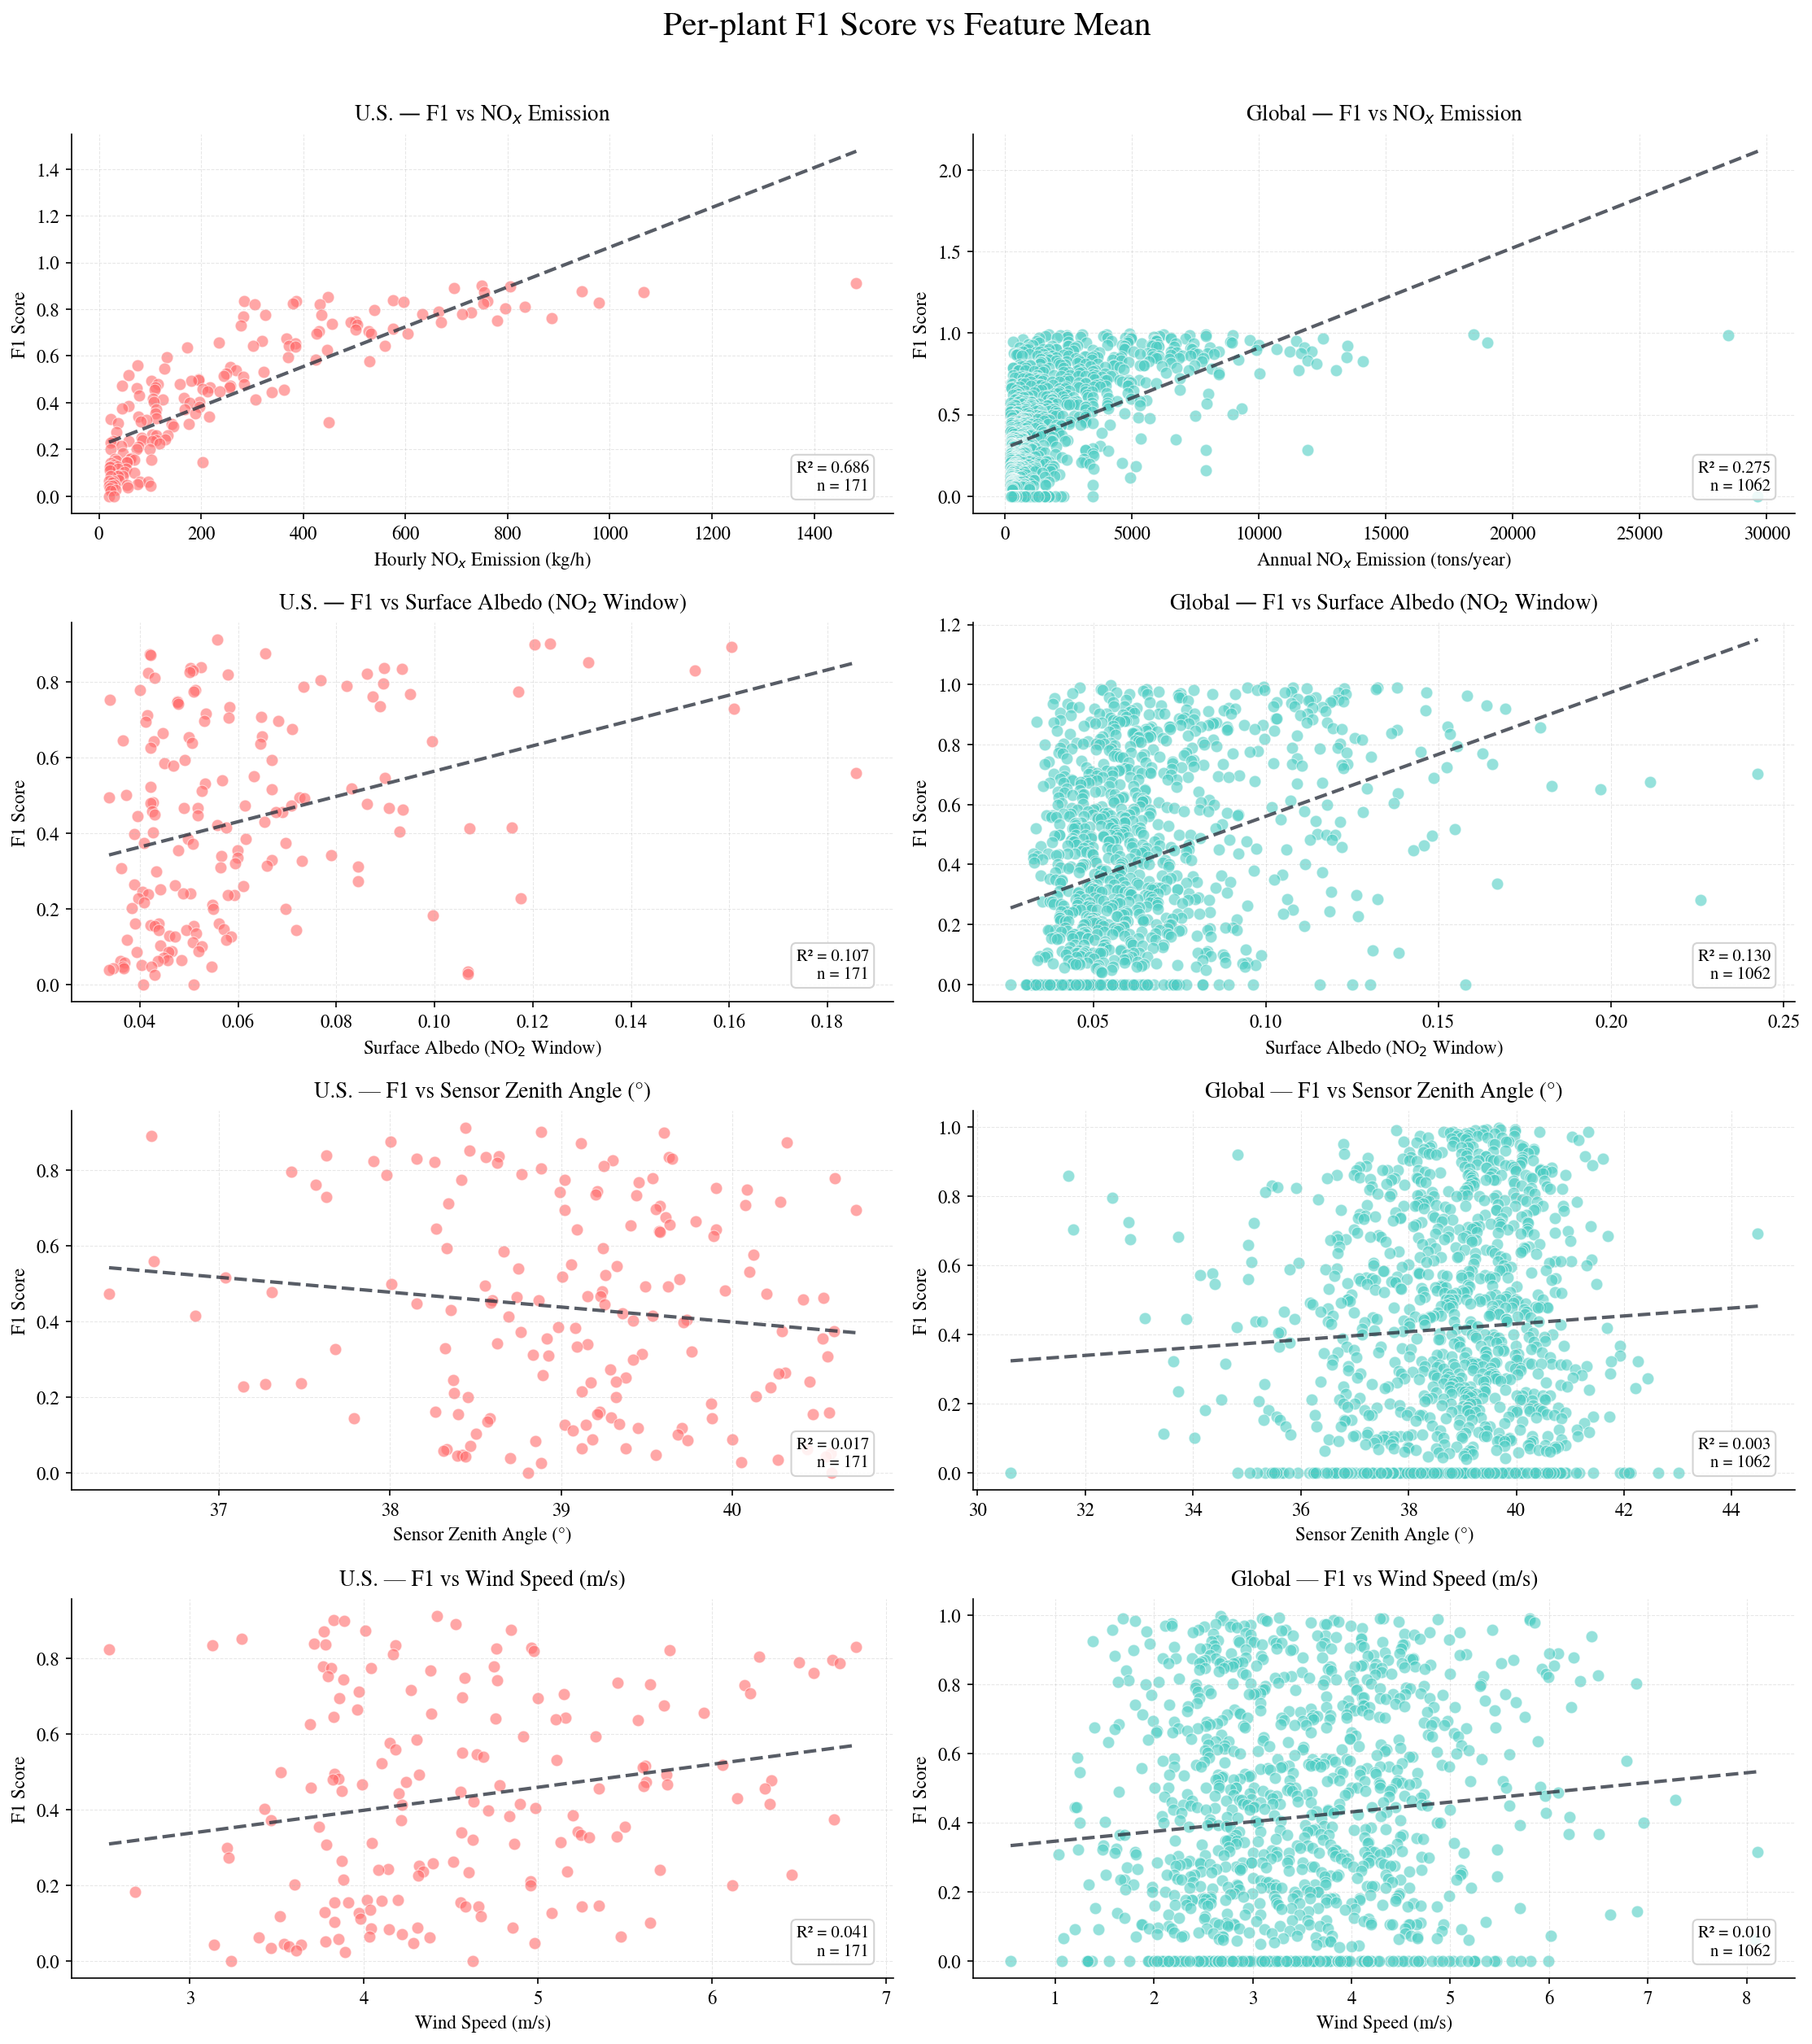

In [5]:
# ── Build 4x2 scatter (rows = features, cols = US/Global) ────────────
def scatter(ax, x, y, color, title, xlabel, ylabel='F1 Score'):
    mask = ~(np.isnan(x) | np.isnan(y))
    x = x[mask]; y = y[mask]
    if len(x) < 3:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                transform=ax.transAxes); ax.set_title(title); return
    ax.scatter(x, y, alpha=0.6, s=50, color=color, edgecolors='white', linewidth=0.5)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xl = np.array([x.min(), x.max()])
    ax.plot(xl, slope*xl + intercept, '--', color='#2E3440', linewidth=2, alpha=0.8)
    ax.text(0.97, 0.05, f'R² = {r**2:.3f}\nn = {len(x)}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85,
                      edgecolor='#cccccc'))
    ax.set_xlabel(xlabel, fontsize=11, fontweight='600')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='600')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(len(FEATURES_LABELS), 2,
                          figsize=(15, 4.2 * len(FEATURES_LABELS)),
                          facecolor='white')
fig.suptitle('Per-plant F1 Score vs Feature Mean', fontsize=20,
              fontweight='bold', y=0.995)

for i, (feat_key, label) in enumerate(FEATURES_LABELS):
    # US
    us_xcol = us_feature_map[feat_key]
    xlabel_us = ('Hourly NO$_x$ Emission (kg/h)' if feat_key == 'emission'
                  else label)
    scatter(axes[i, 0],
            us_merged[us_xcol].values, us_merged['f1'].values,
            COLORS['US'], f'U.S. — F1 vs {label}', xlabel_us)
    # Global
    gl_xcol = gl_feature_map[feat_key]
    xlabel_gl = ('Annual NO$_x$ Emission (tons/year)' if feat_key == 'emission'
                  else label)
    scatter(axes[i, 1],
            gl_merged[gl_xcol].values, gl_merged['f1'].values,
            COLORS['Global'], f'Global — F1 vs {label}', xlabel_gl)

plt.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(OUT_DIR / 'pod_f1_vs_features.pdf', dpi=300, bbox_inches='tight')
fig.savefig(OUT_DIR / 'pod_f1_vs_features.png', dpi=300, bbox_inches='tight')
print('Saved:', OUT_DIR / 'pod_f1_vs_features.pdf')
plt.show()

In [6]:
# ── Print correlation summary table ──────────────────────────────────
print(f'{"Feature":<40s}  {"Region":<8s}  {"R":>8s}  {"R²":>8s}  {"n":>6s}')
print('-' * 78)
for feat_key, label in FEATURES_LABELS:
    for region, df_m, fmap in [('US', us_merged, us_feature_map),
                                ('Global', gl_merged, gl_feature_map)]:
        x = df_m[fmap[feat_key]].values
        y = df_m['f1'].values
        m = ~(np.isnan(x) | np.isnan(y))
        if m.sum() < 3:
            continue
        r = np.corrcoef(x[m], y[m])[0, 1]
        print(f'{label:<40s}  {region:<8s}  {r:>8.4f}  {r**2:>8.4f}  {m.sum():>6d}')

Feature                                   Region           R        R²       n
------------------------------------------------------------------------------
NO$_x$ Emission                           US          0.8280    0.6856     171
NO$_x$ Emission                           Global      0.5244    0.2750    1062
Surface Albedo (NO$_2$ Window)            US          0.3274    0.1072     171
Surface Albedo (NO$_2$ Window)            Global      0.3602    0.1298    1062
Sensor Zenith Angle (°)                   US         -0.1311    0.0172     171
Sensor Zenith Angle (°)                   Global      0.0578    0.0033    1062
Wind Speed (m/s)                          US          0.2027    0.0411     171
Wind Speed (m/s)                          Global      0.0977    0.0095    1062
